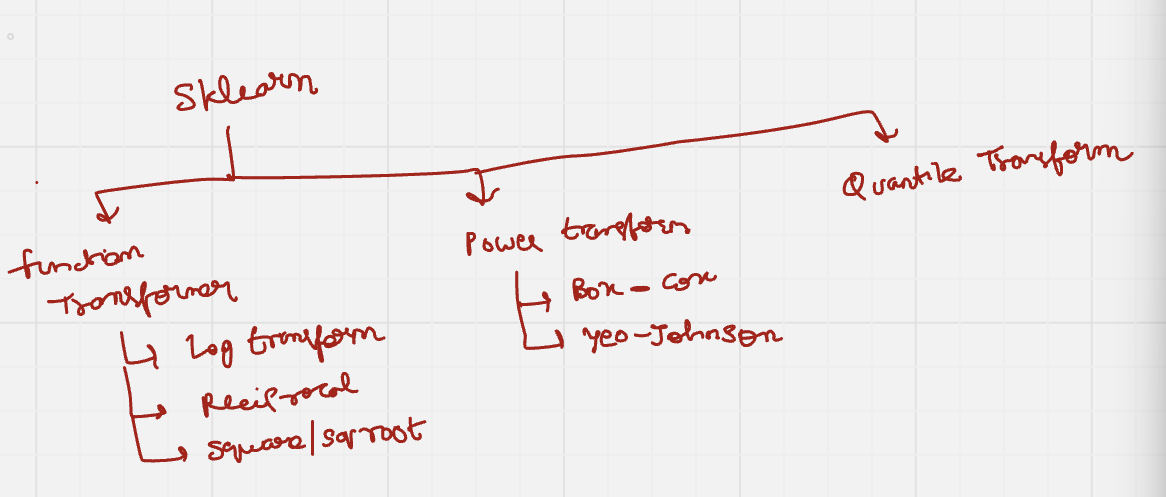

# Normal vs Non-Normal Distribution

In this example, we will generate two datasets:

- a normally distributed dataset using a Gaussian distribution
- a non-normal dataset using an exponential distribution

Then we will compare them using:

- histograms
- Q-Q plots
- the Shapiro-Wilk normality test

If the histogram looks bell-shaped and the Q-Q plot points stay close to a straight line, the data is closer to normal.

In [11]:
# Import libraries and generate sample data
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import FunctionTransformer

np.random.seed(42)

normal_data = np.random.normal(loc=50, scale=10, size=500)
non_normal_data = np.random.exponential(scale=10, size=500)

print('Normal data sample:', normal_data[:5])
print('Non-normal data sample:', non_normal_data[:5])

Normal data sample: [54.96714153 48.61735699 56.47688538 65.23029856 47.65846625]
Non-normal data sample: [10.38224612  8.45781721  4.4020676  43.06195772  9.30833008]


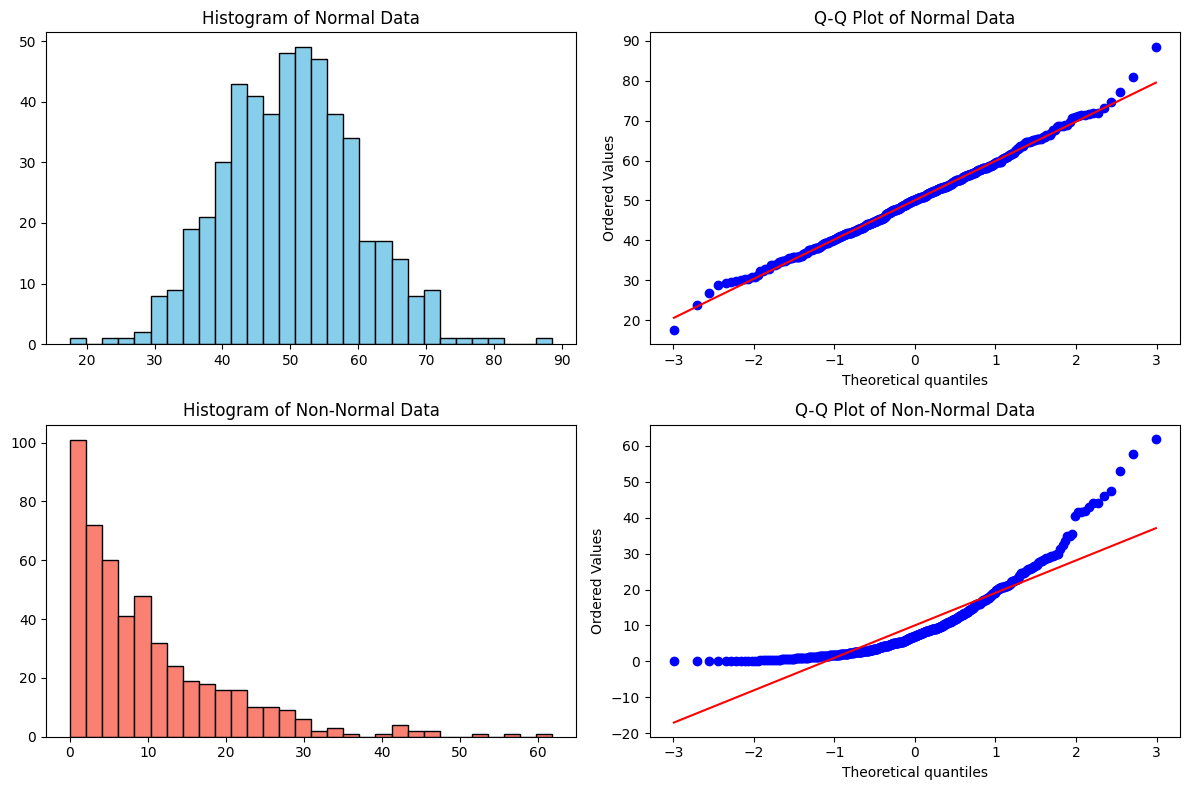

In [12]:
# Plot histograms and Q-Q plots for both datasets
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(normal_data, bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Histogram of Normal Data')

stats.probplot(normal_data, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Normal Data')

axes[1, 0].hist(non_normal_data, bins=30, color='salmon', edgecolor='black')
axes[1, 0].set_title('Histogram of Non-Normal Data')

stats.probplot(non_normal_data, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Non-Normal Data')

plt.tight_layout()
plt.show()

In [13]:
# Use the Shapiro-Wilk test to check normality
normal_stat, normal_p = stats.shapiro(normal_data)
non_normal_stat, non_normal_p = stats.shapiro(non_normal_data)

print('Normal data Shapiro-Wilk p-value:', round(normal_p, 5))
print('Non-normal data Shapiro-Wilk p-value:', round(non_normal_p, 5))

if normal_p > 0.05:
    print('Normal data looks approximately normally distributed.')
else:
    print('Normal data does not look normally distributed.')

if non_normal_p > 0.05:
    print('Non-normal data looks approximately normally distributed.')
else:
    print('Non-normal data does not look normally distributed.')

Normal data Shapiro-Wilk p-value: 0.40127
Non-normal data Shapiro-Wilk p-value: 0.0
Normal data looks approximately normally distributed.
Non-normal data does not look normally distributed.


## Log Transform on Right-Skewed Data

A log transform is often used when data is strongly right-skewed.

It compresses large values more than small values, which usually:

- reduces skewness
- decreases the effect of extreme large values
- makes the distribution look more symmetric
- can make the data closer to normal

In the example below, we generate right-skewed data using an exponential distribution and then apply `np.log1p()`.

We use `log1p(x)` instead of `log(x)` because it safely handles zero values.

Important: a log transform does not guarantee perfectly normal data. It often makes the data *closer* to normal, but the result still depends on the original distribution.

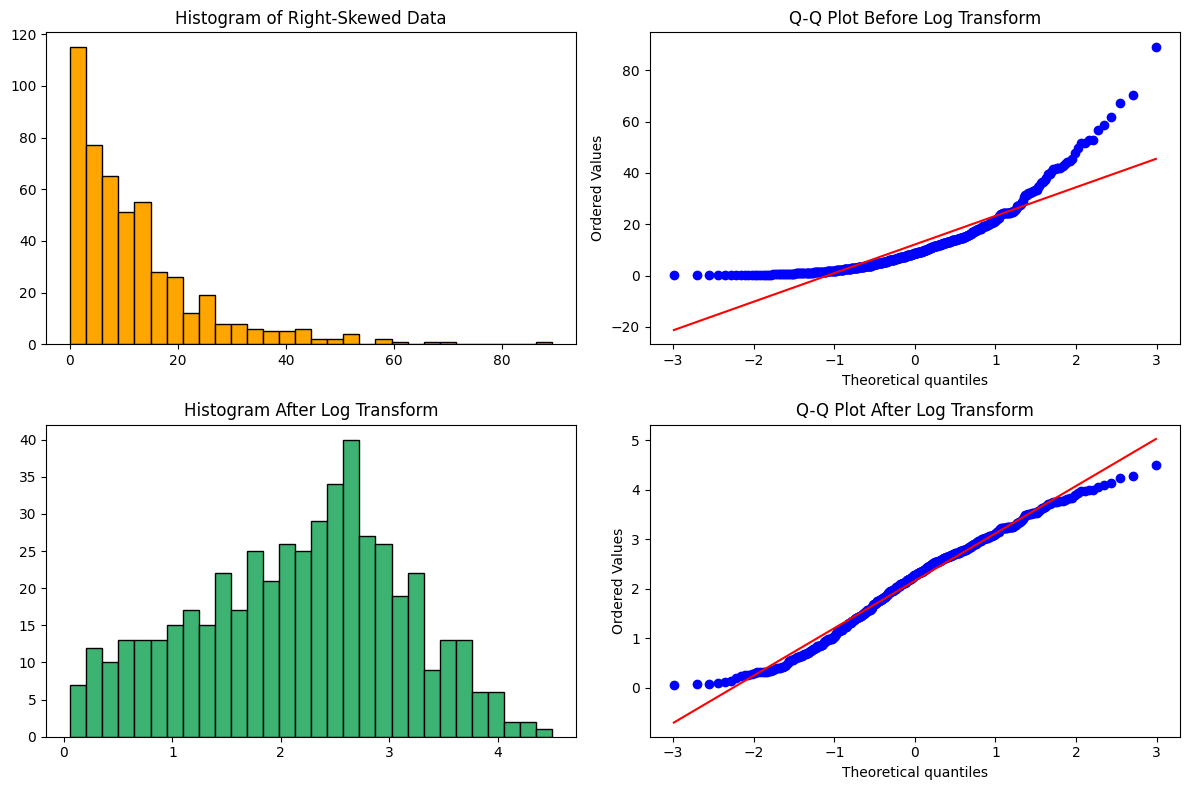

Shapiro-Wilk p-value before log transform: 0.0
Shapiro-Wilk p-value after log transform: 2e-05
The log transform makes the data closer to normal.
After the log transform, the data is still not fully normal.


In [14]:
# Create right-skewed data and apply a log transform with scikit-learn
right_skewed_data = np.random.exponential(scale=12, size=500)
log_transformer = FunctionTransformer(np.log1p, validate=True)
log_transformed_data = log_transformer.fit_transform(right_skewed_data.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(right_skewed_data, bins=30, color='orange', edgecolor='black')
axes[0, 0].set_title('Histogram of Right-Skewed Data')

stats.probplot(right_skewed_data, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot Before Log Transform')

axes[1, 0].hist(log_transformed_data, bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Histogram After Log Transform')

stats.probplot(log_transformed_data, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot After Log Transform')

plt.tight_layout()
plt.show()

before_p = stats.shapiro(right_skewed_data).pvalue
after_p = stats.shapiro(log_transformed_data).pvalue

print('Shapiro-Wilk p-value before log transform:', round(before_p, 5))
print('Shapiro-Wilk p-value after log transform:', round(after_p, 5))

if after_p > before_p:
    print('The log transform makes the data closer to normal.')
else:
    print('The log transform does not make the data closer to normal in this example.')

if after_p > 0.05:
    print('After the log transform, the data looks approximately normal.')
else:
    print('After the log transform, the data is still not fully normal.')

## Square Transform on Left-Skewed Data

For left-skewed data, a square transform can sometimes help make the distribution more balanced.

It tends to stretch larger values more than smaller values, which may reduce negative skewness.

In the example below, we generate left-skewed data and apply a square transform.

Important: just like the log transform, a square transform does not guarantee perfect normality. It only tries to move the data closer to a more symmetric shape.

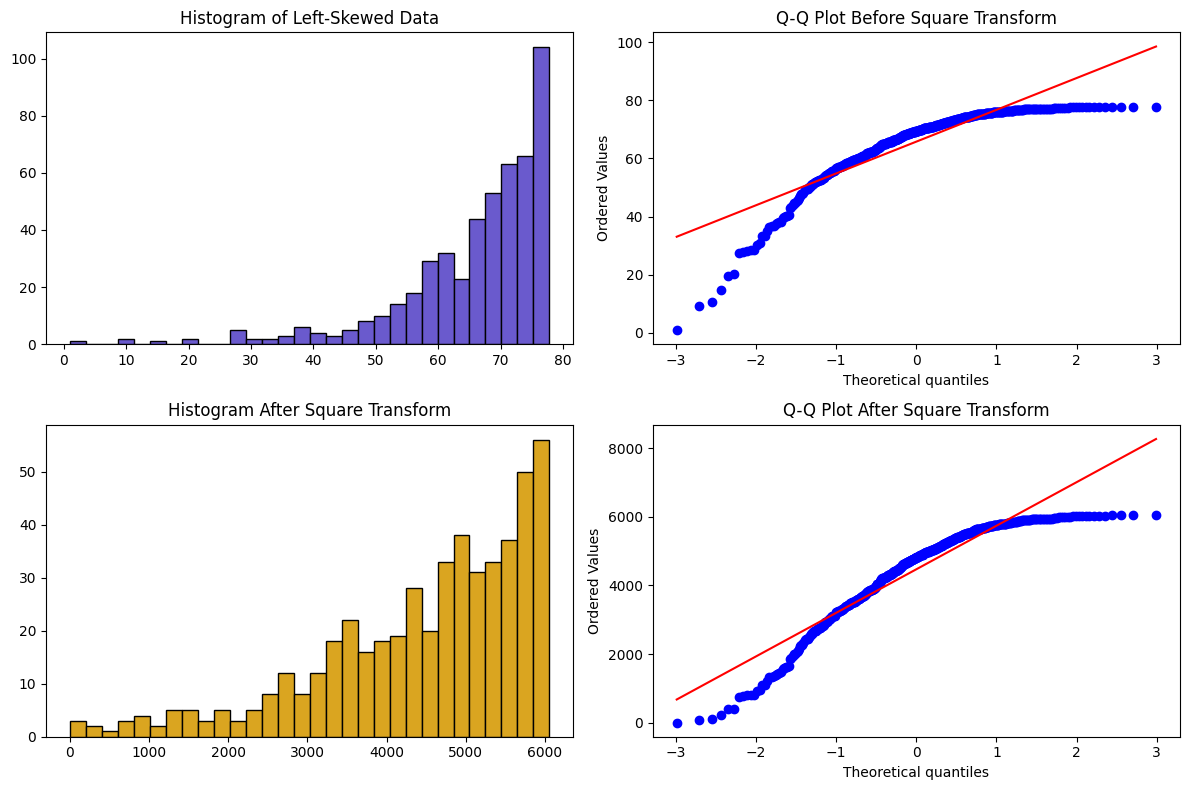

Shapiro-Wilk p-value before square transform: 1.99598e-23
Shapiro-Wilk p-value after square transform: 1.62114e-17
Skewness before square transform: -1.91697
Skewness after square transform: -1.08681
The square transform reduces left skewness and makes the data closer to normal.
After the square transform, the data is still not fully normal.


In [15]:
# Create left-skewed data and apply a square transform with scikit-learn
left_skewed_data = 100 - np.random.exponential(scale=12, size=500)
left_skewed_data = left_skewed_data - left_skewed_data.min() + 1

square_transformer = FunctionTransformer(np.square, validate=True)
squared_transformed_data = square_transformer.fit_transform(left_skewed_data.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(left_skewed_data, bins=30, color='slateblue', edgecolor='black')
axes[0, 0].set_title('Histogram of Left-Skewed Data')

stats.probplot(left_skewed_data, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot Before Square Transform')

axes[1, 0].hist(squared_transformed_data, bins=30, color='goldenrod', edgecolor='black')
axes[1, 0].set_title('Histogram After Square Transform')

stats.probplot(squared_transformed_data, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot After Square Transform')

plt.tight_layout()
plt.show()

before_square_p = stats.shapiro(left_skewed_data).pvalue
after_square_p = stats.shapiro(squared_transformed_data).pvalue
before_skew = stats.skew(left_skewed_data)
after_skew = stats.skew(squared_transformed_data)

print(f'Shapiro-Wilk p-value before square transform: {before_square_p:.5e}')
print(f'Shapiro-Wilk p-value after square transform: {after_square_p:.5e}')
print('Skewness before square transform:', round(before_skew, 5))
print('Skewness after square transform:', round(after_skew, 5))

if abs(after_skew) < abs(before_skew):
    print('The square transform reduces left skewness and makes the data closer to normal.')
else:
    print('The square transform does not improve the left skewness in this example.')

if after_square_p > 0.05:
    print('After the square transform, the data looks approximately normal.')
else:
    print('After the square transform, the data is still not fully normal.')

## Square-Root Transform on Left-Skewed Data

A square-root transform can also be tested on left-skewed data.

Like the square transform, it may reduce negative skewness, but the improvement depends on the data.

Below, we apply a square-root transform to the same left-skewed data and compare the result with histograms, Q-Q plots, and normality statistics.

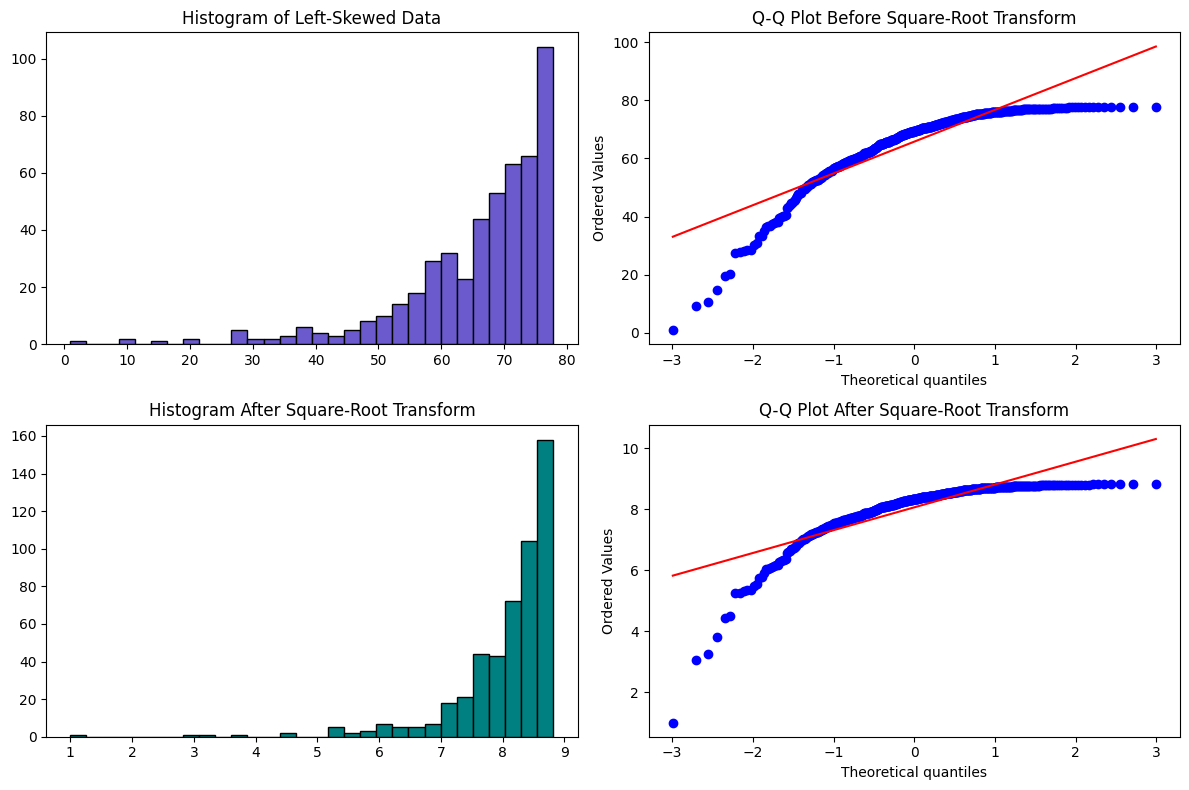

Shapiro-Wilk p-value before square-root transform: 1.99598e-23
Shapiro-Wilk p-value after square-root transform: 5.87252e-28
Skewness before square-root transform: -1.91697
Skewness after square-root transform: -2.98558
The square-root transform does not improve the left skewness in this example.
After the square-root transform, the data is still not fully normal.


In [16]:
# Apply a square-root transform to the same left-skewed data with scikit-learn
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
sqrt_transformed_data = sqrt_transformer.fit_transform(left_skewed_data.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(left_skewed_data, bins=30, color='slateblue', edgecolor='black')
axes[0, 0].set_title('Histogram of Left-Skewed Data')

stats.probplot(left_skewed_data, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot Before Square-Root Transform')

axes[1, 0].hist(sqrt_transformed_data, bins=30, color='teal', edgecolor='black')
axes[1, 0].set_title('Histogram After Square-Root Transform')

stats.probplot(sqrt_transformed_data, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot After Square-Root Transform')

plt.tight_layout()
plt.show()

before_sqrt_p = stats.shapiro(left_skewed_data).pvalue
after_sqrt_p = stats.shapiro(sqrt_transformed_data).pvalue
before_sqrt_skew = stats.skew(left_skewed_data)
after_sqrt_skew = stats.skew(sqrt_transformed_data)

print(f'Shapiro-Wilk p-value before square-root transform: {before_sqrt_p:.5e}')
print(f'Shapiro-Wilk p-value after square-root transform: {after_sqrt_p:.5e}')
print('Skewness before square-root transform:', round(before_sqrt_skew, 5))
print('Skewness after square-root transform:', round(after_sqrt_skew, 5))

if abs(after_sqrt_skew) < abs(before_sqrt_skew):
    print('The square-root transform reduces left skewness and makes the data closer to normal.')
else:
    print('The square-root transform does not improve the left skewness in this example.')

if after_sqrt_p > 0.05:
    print('After the square-root transform, the data looks approximately normal.')
else:
    print('After the square-root transform, the data is still not fully normal.')